# 0. ดึงข้อมูลจริงจาก Traffic API (Real-time Fetch + Coordinate Snapping)

โค้ดชุดนี้เรียก API แผนที่ (เช่น Longdo Map API) เพื่อ:
1. ส่งพิกัด GPS ดิบ (`input_lat`, `input_lon`) ไปถาม API
2. รับพิกัดที่ API จับคู่เข้ากับถนนแล้ว (`matched_lat`, `matched_lon`) พร้อมชื่อถนนและความเร็ว ณ ขณะนั้น
3. คำนวณ `Snapping_Distance` จริง (ระยะห่างระหว่างพิกัดดิบกับพิกัดที่ snap แล้ว หน่วยเมตร) แทนการ hardcode เป็น 0

> ⚠️ ต้องใส่ `API_KEY` และปรับ `BASE_URL` / ชื่อฟิลด์ใน JSON ให้ตรงกับผู้ให้บริการ API ที่คุณใช้จริง (โค้ดด้านล่างเขียนเผื่อโครงสร้าง response ที่พบบ่อยไว้ให้)

In [29]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime

# ตั้งค่า API
API_KEY = '561d8b4b88cfdb6b00410d14df56304a'
BASE_URL = 'https://api.longdo.com/RouteService/json/traffic/speed'
ROUTE_TEST_URL = 'https://api.longdo.com/RouteService/json/route/guide'


def haversine_distance(lat1, lon1, lat2, lon2):
    """ระยะห่าง 2 พิกัด หน่วยเมตร"""
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def test_route_service_access(api_key=API_KEY):
    """เช็คว่า key มีสิทธิ์ Route Service ไหม (ใช้ route/guide ทดสอบ)"""
    params = {
        'flon': 100.538316, 'flat': 13.764953,
        'tlon': 100.5605, 'tlat': 13.7367,
        'key': api_key,
    }
    resp = requests.get(ROUTE_TEST_URL, params=params, timeout=10)
    print('Status:', resp.status_code)
    print('Response:', resp.text[:300])
    return resp


def fetch_traffic_speed(locations, api_key=API_KEY, base_url=BASE_URL,
                         search_range=0.001, max_retries=3, delay=1.0):
    """ดึงความเร็วรถจาก Longdo Traffic Speed API ทีละพิกัด"""
    rows = []

    for loc in locations:
        input_lat, input_lon = loc['lat'], loc['lon']
        target_name = loc.get('name', '')

        payload = {
            'lat': input_lat,
            'lon': input_lon,
            'range': search_range,
            'locale': 'th',
            'key': api_key,
        }

        for attempt in range(max_retries):
            try:
                resp = requests.get(base_url, params=payload, timeout=10)
                resp.raise_for_status()
                data = resp.json()
                break
            except (requests.RequestException, ValueError) as e:
                print(f"⚠️ ล้มเหลว ({target_name}) รอบ {attempt+1}: {e}")
                time.sleep(delay)
        else:
            print(f"❌ ข้าม {target_name} หลังลองครบ {max_retries} ครั้ง")
            continue

        if 'meta' in data and data.get('meta', {}).get('error'):
            print(f"⚠️ Longdo error ที่ {target_name}: {data['meta']}")
            continue

        # field จริงจาก Longdo: road, dir, speed(m/s), source, lon/lat (ตำแหน่ง snap)
        road_name = data.get('road', 'Unknown')
        direction = data.get('dir')
        speed_ms = data.get('speed')
        speed_kmh = speed_ms * 3.6 if speed_ms is not None else None
        source = data.get('source')
        matched_lat = data.get('lat')
        matched_lon = data.get('lon')

        snap_dist = haversine_distance(input_lat, input_lon, matched_lat, matched_lon) \
            if matched_lat is not None and matched_lon is not None else np.nan

        rows.append({
            'scheduled_time': datetime.now(),
            'target_name': target_name,
            'input_lat': input_lat,
            'input_lon': input_lon,
            'matched_lat': matched_lat,
            'matched_lon': matched_lon,
            'response_road': road_name,
            'direction': direction,
            'response_speed': speed_kmh,
            'source': source,
            'Snapping_Distance': snap_dist,
        })

        time.sleep(delay)

    return pd.DataFrame(rows)


In [ ]:
# ตัวอย่างการใช้งาน (uncomment/แก้พิกัดตามต้องการ)
test_route_service_access()

## 0.1 เทียบพิกัด Lat/Lon ที่มีอยู่ กับ Longdo Map API (GetSearchPlace)

อ้างอิงจาก [Longdo Map REST API - GetSearchPlace](https://map.longdo.com/docs/rest?new=true#/operations/GetSearchPlace)

Endpoint จริงเบื้องหลัง operation นี้คือ `https://search.longdo.com/mapsearch/json/search` โค้ดด้านล่างจะ:
1. วนลูปพิกัด (`lat`, `lon`) ที่คุณมีอยู่แล้วในข้อมูล (เช่น `input_lat`/`input_lon` หรือ `matched_lat`/`matched_lon`)
2. ยิง request ไปหา Longdo โดยตั้งพิกัดเป็นจุดศูนย์กลางค้นหา (ไม่ใส่ keyword หรือใส่ span แคบๆ เพื่อเอาสถานที่/ถนนใกล้ที่สุด)
3. ดึงชื่อสถานที่ / ถนนที่ Longdo รู้จักบริเวณนั้น (`name`, `address`) กลับมาเทียบกับ `RoadID` ที่มีอยู่แล้วในข้อมูลของคุณ
4. สรุปว่าตรงกันกี่ % (ไว้เป็นตัวเช็คคุณภาพของ Snapping/RoadID เดิม)

In [30]:
import requests
import pandas as pd
import time
import numpy as np

# คำนวณระยะทาง
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# โหลดข้อมูล
try:
    df_traffic_raw = pd.read_csv('traffic_results.csv', on_bad_lines='skip', encoding='utf-8-sig')
except UnicodeDecodeError:
    try:
        df_traffic_raw = pd.read_csv('traffic_results.csv', on_bad_lines='skip', encoding='tis-620')
    except UnicodeDecodeError:
        df_traffic_raw = pd.read_csv('traffic_results.csv', on_bad_lines='skip', encoding='latin1')
except pd.errors.EmptyDataError:
    print("❌ ไฟล์ 'traffic_results.csv' ว่างเปล่า")
    df_traffic_raw = pd.DataFrame()

if not df_traffic_raw.empty:
    df_traffic_raw = df_traffic_raw.rename(columns={'scheduled_time': 'Datetime', 'response_road': 'RoadID', 'response_speed': 'Current_Speed'})
    if {'input_lat', 'input_lon', 'matched_lat', 'matched_lon'}.issubset(df_traffic_raw.columns):
        df_traffic_raw['Snapping_Distance'] = haversine_distance(
            df_traffic_raw['input_lat'], df_traffic_raw['input_lon'],
            df_traffic_raw['matched_lat'], df_traffic_raw['matched_lon']
        )
    else:
        df_traffic_raw['Snapping_Distance'] = np.nan

# Reverse Geocoding
LONGDO_API_KEY = '561d8b4b88cfdb6b00410d14df56304a'

def get_road_from_coordinate(lat, lon, api_key=LONGDO_API_KEY, max_retries=3, delay=1.0):
    """ดึงที่อยู่/ชื่อถนนจากพิกัด"""
    url = 'https://api.longdo.com/map/services/address'
    params = {'lat': lat, 'lon': lon, 'key': api_key}

    for attempt in range(max_retries):
        try:
            resp = requests.get(url, params=params, timeout=10)
            resp.raise_for_status()
            return resp.json()
        except (requests.RequestException, ValueError) as e:
            print(f"⚠️ ล้มเหลว (lat={lat}, lon={lon}) รอบ {attempt+1}: {e}")
            time.sleep(delay)

    return None

def compare_coordinates_with_api(df, lat_col='matched_lat', lon_col='matched_lon', road_col='RoadID', delay=0.3):
    api_names, api_addresses, is_match = [], [], []

    for _, row in df.iterrows():
        lat, lon = row.get(lat_col), row.get(lon_col)

        if pd.isna(lat) or pd.isna(lon):
            api_names.append(None)
            api_addresses.append(None)
            is_match.append(False)
            continue

        place_data = get_road_from_coordinate(lat, lon)

        if place_data:
            api_road = place_data.get('road', '')
            subdist = place_data.get('subdistrict', '')
            dist = place_data.get('district', '')
            prov = place_data.get('province', '')
            full_address = f"{subdist} {dist} {prov}".strip()
        else:
            api_road = None
            full_address = None

        existing_road = str(row.get(road_col, '')).strip()

        # ตัดคำว่า "ถนน" ออกก่อนเทียบ
        clean_existing = existing_road.replace('ถนน', '').strip()
        clean_api = api_road.replace('ถนน', '').strip() if api_road else ''

        matched = bool(clean_existing and clean_api and (clean_existing in clean_api or clean_api in clean_existing))

        api_names.append(api_road if api_road else None)
        api_addresses.append(full_address if full_address else None)
        is_match.append(matched)

        time.sleep(delay)

    df_result = df.copy()
    df_result['api_place_name'] = api_names
    df_result['api_address'] = api_addresses
    df_result['is_match_with_api'] = is_match
    return df_result

# เรียกใช้งานและแสดงผล
if not df_traffic_raw.empty:
    print("✅ โหลดไฟล์สำเร็จ กำลังตรวจสอบกับ Longdo API...")
    df_check = compare_coordinates_with_api(df_traffic_raw.head(20))

    match_rate = df_check['is_match_with_api'].mean() * 100
    print(f"🎯 อัตราที่ RoadID ตรงกับผล API: {match_rate:.1f}%")

    try:
        display(df_check[['matched_lat', 'matched_lon', 'RoadID', 'api_place_name', 'api_address', 'is_match_with_api']])
    except NameError:
        print(df_check[['matched_lat', 'matched_lon', 'RoadID', 'api_place_name', 'api_address', 'is_match_with_api']])

✅ โหลดไฟล์สำเร็จ กำลังตรวจสอบข้อมูลกับ Longdo Map API...
🎯 อัตราที่ RoadID เดิมตรงกับผล API: 95.0%


,matched_lat,matched_lon,RoadID,api_place_name,api_address,is_match_with_api
0,13.729212,100.778015,ถนนฉลองกรุง,ถนนฉลองกรุง,แขวงลำปลาทิว เขตลาดกระบัง กรุงเทพมหานคร,True
1,13.759773,100.800751,ถนนฉลองกรุง,ถนนฉลองกรุง,แขวงลำปลาทิว เขตลาดกระบัง กรุงเทพมหานคร,True
2,13.804457,100.836357,ถนนฉลองกรุง,ถนนฉลองกรุง,แขวงลำผักชี เขตหนองจอก กรุงเทพมหานคร,True
3,13.727947,100.773514,ฉลองกรุง 1,ฉลองกรุง 1,แขวงลาดกระบัง เขตลาดกระบัง กรุงเทพมหานคร,True
4,13.727834,100.766319,ฉลองกรุง 1,ฉลองกรุง 1,แขวงลาดกระบัง เขตลาดกระบัง กรุงเทพมหานคร,True
5,13.721830,100.779694,ถนนลาดกระบัง,ถนนลาดกระบัง,แขวงลาดกระบัง เขตลาดกระบัง กรุงเทพมหานคร,True
6,13.722533,100.747032,ถนนลาดกระบัง,ถนนลาดกระบัง,แขวงลาดกระบัง เขตลาดกระบัง กรุงเทพมหานคร,True
7,13.721993,100.709869,ถนนลาดกระบัง,ถนนลาดกระบัง,แขวงลาดกระบัง เขตลาดกระบัง กรุงเทพมหานคร,True
8,13.716459,100.805252,ถนนหลวงแพ่ง,ถนนหลวงแพ่ง,แขวงทับยาว เขตลาดกระบัง กรุงเทพมหานคร,True
9,13.701855,100.843887,จุดกลับรถใต้สะพาน,None,แขวงขุมทอง เขตลาดกระบัง กรุงเทพมหานคร,False


# แปลงข้อมูลดิบ ให้เป็น Feature Table

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

def prepare_traffic_features(traffic_df, weather_df):
    # แปลงคอลัมน์ Datetime
    traffic_df['Datetime'] = pd.to_datetime(traffic_df['Datetime'], format='mixed')

    # Feature Gen เบื้องต้น
    traffic_df['Hour'] = traffic_df['Datetime'].dt.hour
    traffic_df['Minute'] = traffic_df['Datetime'].dt.minute
    traffic_df['DayOfWeek'] = traffic_df['Datetime'].dt.dayofweek

    # เพิ่มตัวบอกช่วงเวลาเร่งด่วน (Rush Hour) ชัดๆ ให้ AI รู้
    traffic_df['Is_Rush_Hour'] = ((traffic_df['Hour'].between(7, 9)) | (traffic_df['Hour'].between(17, 19))).astype(int)

    # Data Merging
    weather_df['Datetime'] = pd.to_datetime(weather_df['Datetime'], format='mixed')
    df_merged = pd.merge(traffic_df, weather_df[['Datetime', 'Is_Raining']], on='Datetime', how='left')
    df_merged['Is_Raining'] = df_merged['Is_Raining'].fillna(0)

    # เรียงตาม "ชื่อถนน" และ "เวลา" เสมอ
    df_merged = df_merged.sort_values(by=['RoadID', 'Datetime']).reset_index(drop=True)

    #ดึงความเรขอย้อนหลังหลายรอบ
    df_merged['Historical_Speed_1'] = df_merged.groupby('RoadID')['Current_Speed'].shift(1)
    df_merged['Historical_Speed_2'] = df_merged.groupby('RoadID')['Current_Speed'].shift(2)
    df_merged['Historical_Speed_3'] = df_merged.groupby('RoadID')['Current_Speed'].shift(3)

    #คำนวณความเร็วเฉลี่ยเคลื่อนที่ 3 ช่วงเวลากลุ่มล่าสุด
    df_merged['Speed_Rolling_Mean_3'] = df_merged.groupby('RoadID')['Current_Speed'].rolling(window=3, min_periods=1).mean().reset_index(0, drop=True)

    # ตัวแปรเป้าหมาย (Target)
    df_merged['Target_Speed_Next'] = df_merged.groupby('RoadID')['Current_Speed'].shift(-1)

    # ลบแถวที่เกิด NaN (เนื่องจากการ shift และ rolling)
    df_finalsaktee = df_merged.dropna().reset_index(drop=True)

    print("GOOD BOY - Features Upgraded!")

    # อัปเดตรายชื่อฟีเจอร์ที่จะเอาไปเทรนโมเดล
    feature_columns = [
        'Datetime', 'RoadID', 'Hour', 'Minute', 'DayOfWeek', 'Is_Rush_Hour',
        'Snapping_Distance', 'Is_Raining',
        'Historical_Speed_1', 'Historical_Speed_2', 'Historical_Speed_3',
        'Speed_Rolling_Mean_3', 'Current_Speed', 'Target_Speed_Next'
    ]

    return df_finalsaktee[feature_columns]

# แบ่งข้อมูลและเตรียม x (Features) และ y (Target)

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูลเดิม
df_traffic_raw = pd.read_csv('traffic_results.csv', on_bad_lines='skip')
df_weather_raw = pd.read_csv('thai_accidental_dataset.csv', on_bad_lines='skip', encoding='latin1')

df_traffic_raw = df_traffic_raw.rename(columns={'scheduled_time': 'Datetime', 'response_road': 'RoadID', 'response_speed': 'Current_Speed'})
# คำนวณ Snapping_Distance จริงจากพิกัด input vs matched (ถ้าไฟล์มีคอลัมน์เหล่านี้)
if {'input_lat', 'input_lon', 'matched_lat', 'matched_lon'}.issubset(df_traffic_raw.columns):
    df_traffic_raw['Snapping_Distance'] = haversine_distance(
        df_traffic_raw['input_lat'], df_traffic_raw['input_lon'],
        df_traffic_raw['matched_lat'], df_traffic_raw['matched_lon']
    )
else:
    print('⚠️ ไม่พบคอลัมน์พิกัด input/matched ใน traffic_results.csv จึงตั้ง Snapping_Distance เป็น NaN (ควรเพิ่มคอลัมน์เหล่านี้ตอนดึงจาก API)')
    df_traffic_raw['Snapping_Distance'] = np.nan
df_weather_raw = df_weather_raw.rename(columns={'time': 'Datetime', 'weather': 'Is_Raining'})

# 2. รวมข้อมูล (ใช้ฟังก์ชันเดิมของคุณ)
df_finalsaktee = prepare_traffic_features(df_traffic_raw, df_weather_raw)
df_finalsaktee['Datetime'] = pd.to_datetime(df_finalsaktee['Datetime'])

# 3. แปลงเวลา (Cyclical Encoding)
hours = df_finalsaktee['Datetime'].dt.hour
days = df_finalsaktee['Datetime'].dt.dayofweek
df_finalsaktee['Hour_Sin'] = np.sin(2 * np.pi * hours / 24)
df_finalsaktee['Hour_Cos'] = np.cos(2 * np.pi * hours / 24)
df_finalsaktee['Day_Sin'] = np.sin(2 * np.pi * days / 7)
df_finalsaktee['Day_Cos'] = np.cos(2 * np.pi * days / 7)
df_finalsaktee['Is_Weekend'] = days.apply(lambda x: 1 if x >= 5 else 0)

# 4. สร้าง Target (ระดับความเสี่ยงรถติด)
def categorize_risk(speed):
    if speed < 20: return 2 # High Risk
    elif speed <= 45: return 1 # Medium Risk
    else: return 0 # Low Risk

df_finalsaktee['Risk_Level'] = df_finalsaktee['Target_Speed_Next'].apply(categorize_risk)

# 5. แบ่ง X, y
X = df_finalsaktee.drop(columns=['Datetime', 'Target_Speed_Next', 'Risk_Level'])
y = df_finalsaktee['Risk_Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print("✅ เตรียมข้อมูลเสร็จสิ้น (ตัดอุบัติเหตุออกแล้ว)")

GOOD BOY - Features Upgraded!
✅ เตรียมข้อมูลเสร็จสิ้น (ตัดอุบัติเหตุออกแล้ว)


/tmp/ipykernel_1082/3911354281.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['Is_Raining'] = df_merged['Is_Raining'].fillna(0)


In [33]:
import pandas as pd

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Fix: Changed 'Target_Speed_Next' to 'Risk_Level' as y_train contains Risk_Level
road_target_mean = X_train.join(y_train).groupby('RoadID')['Risk_Level'].mean()

X_train_encoded['RoadID_Encoded'] = X_train_encoded['RoadID'].map(road_target_mean)
X_test_encoded['RoadID_Encoded'] = X_test_encoded['RoadID'].map(road_target_mean).fillna(road_target_mean.mean())

X_train_encoded = X_train_encoded.drop(columns=['RoadID'])
X_test_encoded = X_test_encoded.drop(columns=['RoadID'])

X_train_encoded = X_train_encoded.fillna(0)
X_test_encoded = X_test_encoded.fillna(0)

print(f"จำนวนฟีเจอร์ตอนนี้: {X_train_encoded.shape[1]} คอลัมน์ (ลดลงจากเดิมมหาศาลและแน่นขึ้น)")

จำนวนฟีเจอร์ตอนนี้: 17 คอลัมน์ (ลดลงจากเดิมมหาศาลและแน่นขึ้น)


# แปลงข้อมูลถนน ก่อนเข้าโมเดล


In [34]:
from sklearn.metrics import mean_absolute_error
import pandas as pd

#one-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=['RoadID'])
X_test_encoded = pd.get_dummies(X_test, columns=['RoadID'])

# ปรับคอลัมน์ของข้อสอบ (Test) ให้มีจำนวนเท่ากับตอนเรียน (Train) เผื่อมีถนนบางเส้นโผล่มาไม่ครบ
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


# Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)
lr_pred = lr_model.predict(X_test_encoded)

lr_error = mean_absolute_error(y_test, lr_pred)
print(f"Er: {lr_error:.2f} กม./ชม.")

Er: 0.45 กม./ชม.


# Decision Tree

In [36]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_encoded, y_train)
dt_pred = dt_model.predict(X_test_encoded)

dt_error = mean_absolute_error(y_test, dt_pred)
print(f"Error: {dt_error:.2f} กม./ชม.")

Error: 0.40 กม./ชม.


# Random Forest

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_encoded, y_train)
rf_pred = rf_model.predict(X_test_encoded)

rf_error = mean_absolute_error(y_test, rf_pred)
print(f"Error: {rf_error:.2f} กม./ชม.")

Error: 0.39 กม./ชม.


# KNN

In [38]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_encoded, y_train)
knn_pred = knn_model.predict(X_test_encoded)

knn_error = mean_absolute_error(y_test, knn_pred)
print(f"Error: {knn_error:.2f} กม./ชม.")

Error: 0.36 กม./ชม.


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# คำนวณ Metrics เพิ่มเติม
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
rf_r2 = r2_score(y_test, rf_pred)

print("\n=== สรุปผล Random Forest ===")
print(f"MAE (Error เฉลี่ย): {rf_error:.2f} กม./ชม.")
print(f"RMSE (Error ถ่วงน้ำหนัก): {rf_rmse:.2f} กม./ชม.")
print(f"MAPE (Error เป็น %): {rf_mape:.2f}%")
print(f"R-squared: {rf_r2:.4f}")


=== สรุปผล Random Forest ===
MAE (Error เฉลี่ย): 0.39 กม./ชม.
RMSE (Error ถ่วงน้ำหนัก): 0.54 กม./ชม.
MAPE (Error เป็น %): 35.29%
R-squared: -0.2435


# XGBoost No.1


In [40]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

final_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

final_xgb_model.fit(X_train_encoded, y_train)
final_pred = final_xgb_model.predict(X_test_encoded)
final_error = mean_absolute_error(y_test, final_pred)

print(f"XGBoost Error: {final_error:.2f} กม./ชม.")

XGBoost Error: 0.41 กม./ชม.


# เทรนโมเดล LSTM

> Add blockquote



In [41]:
resp = requests.get(BASE_URL, params=payload, timeout=10)
print("Status code:", resp.status_code)
print("Raw response:", resp.text[:500])  # ดูแค่ 500 ตัวอักษรแรกพอ

Status code: 200
Raw response: throw 'Route Service API Key Error';


In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report # 💡 เปลี่ยนตัวชี้วัด

# 1. ปรับสเกลข้อมูล
X_train_numeric = X_train_encoded.astype(float)
X_test_numeric = X_test_encoded.astype(float)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# 2. Sliding Window (ใช้ 5 สเตปเหมือนเดิม)
def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    y_array = y.to_numpy() if hasattr(y, 'to_numpy') else np.array(y)
    for i in range(len(X) - time_steps):
        Xs.append(X[i : (i + time_steps)])
        ys.append(y_array[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_train_lstm, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS)
X_test_lstm, y_test_seq = create_sequences(X_test_scaled, y_test, TIME_STEPS)

# 🌟 3. อัปเกรดเป็น Classification Model (คาดการณ์ความเสี่ยง)
lstm_model_risk = Sequential([
    tf.keras.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Bidirectional(LSTM(64, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    # 💡 เปลี่ยนชั้นสุดท้ายเป็น 3 Node และใช้ softmax เพื่อคายค่าความน่าจะเป็นของ 3 ระดับความเสี่ยง
    Dense(3, activation='softmax')
])

# 💡 เปลี่ยน Loss เป็น sparse_categorical_crossentropy และตั้ง metric เป็น accuracy
lstm_model_risk.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

print("กำลังเทรนโมเดลประเมินความเสี่ยงจราจร กรุณารอสักครู่...")
history = lstm_model_risk.fit(
    X_train_lstm, y_train_seq,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_seq),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 4. ดูผลลัพธ์แบบ Classification
risk_pred_probs = lstm_model_risk.predict(X_test_lstm)
# 💡 แปลงความน่าจะเป็นให้กลายเป็นคลาสที่โมเดลมั่นใจที่สุด (0, 1 หรือ 2)
risk_pred = np.argmax(risk_pred_probs, axis=1)

print(f"Accuracy (ความแม่นยำรวม): {accuracy_score(y_test_seq, risk_pred) * 100:.2f}%\n")
print("รายละเอียดประสิทธิภาพแยกตามระดับความเสี่ยง:")
print("(0 = Low Risk, 1 = Medium Risk, 2 = High Risk)")
print(classification_report(y_test_seq, risk_pred))

กำลังเทรนโมเดลประเมินความเสี่ยงจราจร กรุณารอสักครู่...
Epoch 1/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8614 - loss: 0.3136 - val_accuracy: 0.6420 - val_loss: 0.7411 - learning_rate: 0.0050
Epoch 2/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8736 - loss: 0.2836 - val_accuracy: 0.6727 - val_loss: 0.6408 - learning_rate: 0.0050
Epoch 3/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8755 - loss: 0.2764 - val_accuracy: 0.6639 - val_loss: 0.6607 - learning_rate: 0.0050
Epoch 4/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8758 - loss: 0.2744 - val_accuracy: 0.6433 - val_loss: 0.6481 - learning_rate: 0.0050
Epoch 5/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8766 - loss: 0.2731 - val_accuracy: 0.6500 - val_loss: 0.6704 - learning_rate: 0.0050
Epoch 6/150
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8768 - loss: 0.2722 - val_accuracy: 0.6484 - val_loss: 0.6525 - learning_rate: 0.0050
Epoch 7/150
144

⚖️ น้ำหนักที่ปรับให้โมเดล: {np.int64(0): np.float64(7.691704223001168), np.int64(1): np.float64(1.791919427593716), np.int64(2): np.float64(0.4325392355635654)}
กำลังเทรนโมเดล...
Epoch 1/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7002 - loss: 0.6312 - val_accuracy: 0.7439 - val_loss: 0.5197 - learning_rate: 0.0010
Epoch 2/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7478 - loss: 0.3879 - val_accuracy: 0.7596 - val_loss: 0.4697 - learning_rate: 0.0010
Epoch 3/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7543 - loss: 0.3646 - val_accuracy: 0.7618 - val_loss: 0.5007 - learning_rate: 0.0010
Epoch 4/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7604 - loss: 0.3555 - val_accuracy: 0.7994 - val_loss: 0.4216 - learning_rate: 0.0010
Epoch 5/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7734 - loss: 0.3463 - val_accuracy: 0.7972 - val_loss: 0.4438 - learning_rate: 0.0010
Epoch 6/150
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 11

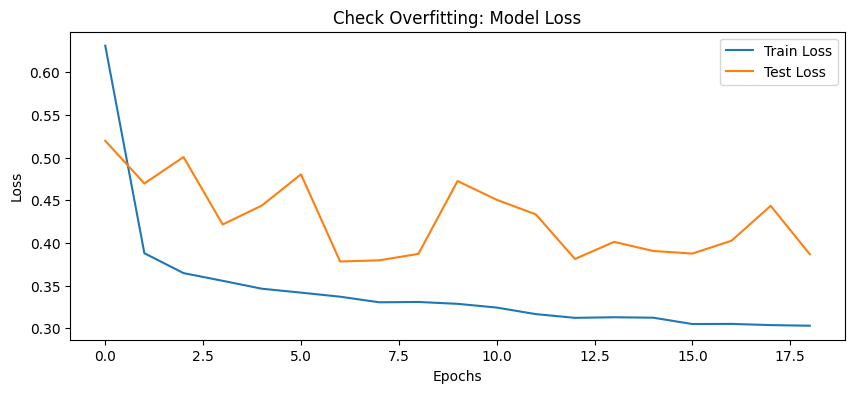

361/361 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== 🏆 ผลลัพธ์หลังแก้ไข ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       499
           1       0.57      0.72      0.64      2143
           2       0.93      0.87      0.90      8879

    accuracy                           0.85     11521
   macro avg       0.83      0.86      0.84     11521
weighted avg       0.86      0.85      0.85     11521



In [52]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# ==========================================
# 1. เตรียมข้อมูลแบบใหม่ (แก้ปัญหาคลาส 0 หาย)
# ==========================================
# รวม X และ y ก่อนสเกล (สมมติว่าคุณมี X และ y เต็มๆ ก่อนหน้านี้)
# เราจะทำ Scaling ทีเดียวทั้งหมด แล้วค่อยสร้าง Sequence

# Fix: One-hot encode the 'RoadID' column in the full X DataFrame before scaling
X_processed = pd.get_dummies(X, columns=['RoadID'])

scaler = MinMaxScaler()
X_scaled_all = scaler.fit_transform(X_processed.astype(float)) # X_processed should now be all numeric

def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    y_array = y.to_numpy() if hasattr(y, 'to_numpy') else np.array(y)
    for i in range(len(X) - time_steps):
        Xs.append(X[i : (i + time_steps)])
        ys.append(y_array[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
# สร้าง Sequence จากข้อมูลทั้งหมดก่อน
X_lstm_all, y_seq_all = create_sequences(X_scaled_all, y, TIME_STEPS)

# 🌟 ทริคสำคัญ: แบ่งข้อมูล "หลังจาก" สร้าง Sequence แล้วสับไพ่แบบแบ่งสัดส่วน (stratify)
X_train_lstm, X_test_lstm, y_train_seq, y_test_seq = train_test_split(
    X_lstm_all, y_seq_all, test_size=0.20, stratify=y_seq_all, random_state=42
)

# ==========================================
# 2. สร้างตัวถ่วงน้ำหนัก (Class Weights)
# ==========================================
classes = np.unique(y_train_seq)
weights = compute_class_weight('balanced', classes=classes, y=y_train_seq)
class_weights_dict = dict(zip(classes, weights))
print(f"⚖️ น้ำหนักที่ปรับให้โมเดล: {class_weights_dict}")

# ==========================================
# 3. โครงสร้างโมเดล (ลดความฉลาดลง แก้อาการจำข้อสอบ)
# ==========================================
lstm_model_risk = Sequential([
    tf.keras.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    # ลด Node จาก 64 เหลือ 16 และใส่ L2 Regularization เตะตัดขาไม่ให้ค่าน้ำหนักโดด
    Bidirectional(LSTM(16, activation='tanh', kernel_regularizer=tf.keras.regularizers.l2(0.01))),
    Dropout(0.5),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(3, activation='softmax')
])

lstm_model_risk.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🌟 แก้ไขค่า Patience ให้ถูกต้อง (EarlyStop ต้องมากกว่า ReduceLR)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("กำลังเทรนโมเดล...")
history = lstm_model_risk.fit(
    X_train_lstm, y_train_seq,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_seq),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)

# ==========================================
# 4. วาดกราฟและประเมินผล
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Check Overfitting: Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

risk_pred_probs = lstm_model_risk.predict(X_test_lstm)
risk_pred = np.argmax(risk_pred_probs, axis=1)

print("\n=== 🏆 ผลลัพธ์หลังแก้ไข ===")
print(classification_report(y_test_seq, risk_pred))

# 6. Real-time Prediction & Evaluation Pipeline

ส่วนนี้ต่อยอดจากโมเดลที่เทรนไว้แล้วด้านบน โดยไม่แก้โค้ดเดิม เพิ่มแค่ pipeline สำหรับ:
1. เทรนโมเดลทำนาย **ความเร็วจริง (กม./ชม.)** แยกจากโมเดล Risk_Level เดิม (เพราะ y เดิมเป็นคนละหน่วยกัน)
2. ดึงข้อมูลจาก Longdo API ปัจจุบัน → สร้าง feature แบบเดียวกับตอนเทรน → ทำนายอีก 15 นาทีข้างหน้า
3. รอครบ 15 นาที → ดึง API อีกครั้ง → เทียบ Predict vs Actual → คำนวณ Error
4. เก็บผลทุกครั้งลง CSV แล้วสรุป MAE / RMSE / MAPE จากข้อมูลจริง

## 6.1 เทรนโมเดลทำนายความเร็วจริง + save_model / load_model

In [ ]:
import joblib

# y เดิมคือ Risk_Level ไม่ใช่ความเร็ว -> ดึง Target_Speed_Next (กม./ชม. จริง) มาแทน ด้วย index เดียวกับ X_train/X_test
y_train_speed = df_finalsaktee.loc[X_train.index, 'Target_Speed_Next']
y_test_speed = df_finalsaktee.loc[X_test.index, 'Target_Speed_Next']

FEATURE_COLUMNS = list(X_train_encoded.columns)  # ต้องใช้ชุดเดียวกันตอน predict จริง


def train_model(X_train_enc, y_train_target, params=None):
    """เทรนโมเดลทำนายความเร็ว (XGBRegressor)"""
    from xgboost import XGBRegressor
    default_params = dict(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
    if params:
        default_params.update(params)
    model = XGBRegressor(**default_params)
    model.fit(X_train_enc, y_train_target)
    return model


def save_model(model, model_path='speed_model.json', meta_path='speed_model_meta.joblib'):
    """เซฟ booster ด้วย native format ของ XGBoost (ไม่ผูกเวอร์ชัน) + เมทาดาต้าแยกไฟล์"""
    model.save_model(model_path)
    meta = {'feature_columns': FEATURE_COLUMNS, 'road_target_mean': road_target_mean if 'road_target_mean' in dir() else None}
    joblib.dump(meta, meta_path)
    print(f"✅ บันทึกโมเดลไว้ที่ {model_path} และ {meta_path}")


def load_model(model_path='speed_model.json', meta_path='speed_model_meta.joblib'):
    """โหลด booster + เมทาดาต้ากลับมา คืนค่าเป็น dict {'model', 'feature_columns', 'road_target_mean'}"""
    from xgboost import XGBRegressor
    model = XGBRegressor()
    model.load_model(model_path)
    meta = joblib.load(meta_path)
    print(f"✅ โหลดโมเดลจาก {model_path}")
    return {'model': model, **meta}


speed_model = train_model(X_train_encoded, y_train_speed)

speed_pred_test = speed_model.predict(X_test_encoded)
speed_mae = mean_absolute_error(y_test_speed, speed_pred_test)
print(f"Offline MAE (ความเร็วจริง): {speed_mae:.2f} กม./ชม.")

save_model(speed_model)  # จะได้ speed_model.json + speed_model_meta.joblib

## 6.2 ดึงข้อมูลปัจจุบัน + สร้าง Feature ให้ตรงกับตอนเทรน + ทำนาย

In [ ]:
from collections import defaultdict

# เก็บความเร็วย้อนหลังของแต่ละถนนไว้ในหน่วยความจำ (สำหรับสร้าง Historical_Speed_1/2/3 และ Rolling Mean)
speed_history = defaultdict(list)  # {RoadID: [speed_t-3, speed_t-2, speed_t-1, speed_t]}


def fetch_current_data(locations):
    """ดึงข้อมูลปัจจุบันจาก Longdo (reuse fetch_traffic_speed เดิม)"""
    return fetch_traffic_speed(locations)


def build_features(row, is_raining=0):
    """สร้าง feature 1 แถว ให้ตรงกับ FEATURE_COLUMNS ตอนเทรนทุกประการ"""
    now = row['scheduled_time']
    road = row['target_name']
    speed_now = row['response_speed']

    hist = speed_history[road]
    hist.append(speed_now)
    speed_history[road] = hist[-4:]  # เก็บแค่ 4 ค่าล่าสุดพอ

    def lag(n):
        return hist[-1 - n] if len(hist) > n else speed_now

    hour, day = now.hour, now.weekday()

    feat = {
        'Hour': hour,
        'Minute': now.minute,
        'DayOfWeek': day,
        'Is_Rush_Hour': int((7 <= hour <= 9) or (17 <= hour <= 19)),
        'Snapping_Distance': row.get('Snapping_Distance', 0),
        'Is_Raining': is_raining,
        'Historical_Speed_1': lag(1),
        'Historical_Speed_2': lag(2),
        'Historical_Speed_3': lag(3),
        'Speed_Rolling_Mean_3': sum(hist[-3:]) / len(hist[-3:]),
        'Current_Speed': speed_now,
        'Hour_Sin': np.sin(2 * np.pi * hour / 24),
        'Hour_Cos': np.cos(2 * np.pi * hour / 24),
        'Day_Sin': np.sin(2 * np.pi * day / 7),
        'Day_Cos': np.cos(2 * np.pi * day / 7),
        'Is_Weekend': int(day >= 5),
    }

    feat_df = pd.DataFrame([feat])
    feat_df = pd.get_dummies(feat_df)
    feat_df[f'RoadID_{road}'] = 1  # จำลอง one-hot ของถนนนี้
    feat_df = feat_df.reindex(columns=FEATURE_COLUMNS, fill_value=0)
    return feat_df


def predict_speed(model, feat_df):
    return float(model.predict(feat_df)[0])

## 6.3 Pipeline หลัก: ทำนายตอนนี้ → รอ 15 นาที → เทียบกับ Actual

In [ ]:
import os

PENDING_FILE = 'pending_predictions.csv'
EVAL_LOG_FILE = 'evaluation_log.csv'
HORIZON_MINUTES = 15


def run_prediction_cycle(locations, model=speed_model, horizon_minutes=HORIZON_MINUTES):
    """ดึงข้อมูลตอนนี้ ทำนายความเร็วอีก horizon_minutes นาทีข้างหน้า แล้วบันทึกไว้รอเทียบ"""
    df_now = fetch_current_data(locations)
    if df_now.empty:
        print("⚠️ ไม่ได้ข้อมูลจาก API ข้ามรอบนี้")
        return

    rows = []
    for _, row in df_now.iterrows():
        feat_df = build_features(row)
        pred = predict_speed(model, feat_df)
        due_time = row['scheduled_time'] + pd.Timedelta(minutes=horizon_minutes)

        rows.append({
            'road': row['target_name'],
            'predict_time': row['scheduled_time'],
            'due_time': due_time,
            'current_speed': row['response_speed'],
            'predicted_speed': pred,
        })
        print(f"{row['target_name']}: ตอนนี้ {row['response_speed']:.1f} km/h -> ทำนาย {due_time.strftime('%H:%M')} = {pred:.1f} km/h")

    df_pending = pd.DataFrame(rows)
    header = not os.path.exists(PENDING_FILE)
    df_pending.to_csv(PENDING_FILE, mode='a', header=header, index=False)


def check_due_predictions(locations):
    """เช็คว่ามีคำทำนายไหนถึงเวลาแล้ว ถ้าถึง ดึง Actual มาเทียบ แล้วบันทึกผล error"""
    if not os.path.exists(PENDING_FILE):
        print("ยังไม่มีคำทำนายค้างอยู่")
        return

    df_pending = pd.read_csv(PENDING_FILE, parse_dates=['predict_time', 'due_time'])
    now = pd.Timestamp.now()
    due_mask = df_pending['due_time'] <= now

    if not due_mask.any():
        print("ยังไม่ถึงเวลาเช็คของคำทำนายไหนเลย")
        return

    df_actual_now = fetch_current_data(locations)
    actual_map = dict(zip(df_actual_now['target_name'], df_actual_now['response_speed']))

    due_rows = df_pending[due_mask].copy()
    due_rows['actual_speed'] = due_rows['road'].map(actual_map)
    due_rows = due_rows.dropna(subset=['actual_speed'])
    due_rows['error'] = (due_rows['predicted_speed'] - due_rows['actual_speed']).abs()

    header = not os.path.exists(EVAL_LOG_FILE)
    due_rows.to_csv(EVAL_LOG_FILE, mode='a', header=header, index=False)

    # เอาแถวที่เช็คแล้วออกจาก pending
    df_pending[~due_mask].to_csv(PENDING_FILE, index=False)

    print(f"✅ เช็คแล้ว {len(due_rows)} รายการ, บันทึกลง {EVAL_LOG_FILE}")

## 6.4 สรุปความแม่นยำจากข้อมูลจริง (Online Evaluation)

In [ ]:
def evaluate_prediction(log_file=EVAL_LOG_FILE):
    """อ่าน evaluation log แล้วคำนวณ MAE / RMSE / MAPE จาก Predict vs Actual จริง"""
    if not os.path.exists(log_file):
        print("ยังไม่มีข้อมูลประเมินผล ลองรัน run_prediction_cycle + check_due_predictions ก่อน")
        return None

    df_log = pd.read_csv(log_file)
    mae = mean_absolute_error(df_log['actual_speed'], df_log['predicted_speed'])
    rmse = np.sqrt(mean_squared_error(df_log['actual_speed'], df_log['predicted_speed']))
    mape = mean_absolute_percentage_error(df_log['actual_speed'], df_log['predicted_speed']) * 100

    print(f"จำนวนคู่ Predict/Actual ที่ใช้ประเมิน: {len(df_log)}")
    print(f"MAE (Real-time): {mae:.2f} กม./ชม.")
    print(f"RMSE (Real-time): {rmse:.2f} กม./ชม.")
    print(f"MAPE (Real-time): {mape:.2f}%")

    return df_log


# วิธีใช้งานจริง:
# locations = [{'name': 'แยกอโศก', 'lat': 13.7367, 'lon': 100.5605}]
# run_prediction_cycle(locations)          # รันตอนนี้ (t=0)
# ... รอ 15 นาที (หรือตั้ง schedule ให้รันซ้ำทุก 1-5 นาที) ...
# check_due_predictions(locations)         # เช็คว่าถึงเวลาไหม ถ้าถึงจะบันทึก error
# evaluate_prediction()                    # ดูสรุป MAE/RMSE/MAPE จากของจริง

## 6.5 หมายเหตุเรื่อง Data Leakage (ข้อ 5 ที่ถามมา)

`train_test_split(..., shuffle=False)` ที่ใช้อยู่ตอนนี้ **ไม่ได้สุ่มสลับ** และข้อมูลถูก sort ตาม `RoadID` แล้ว `Datetime` ก่อนแบ่งแล้ว จึงเป็น time-based split อยู่แล้วในระดับหนึ่ง ไม่ใช่การสุ่มแบบสุ่มทั่วไป

แต่ยังไม่ใช่ Walk-forward Validation เต็มรูปแบบ (เทรนซ้ำทีละ fold ตามเวลา) — ถ้าต้องการความเข้มงวดขึ้น สามารถใช้ `sklearn.model_selection.TimeSeriesSplit` แทนได้ในภายหลัง แต่สำหรับตอนนี้ยังไม่ถือว่า leak เพราะไม่มีการสลับอนาคตไปอยู่ใน train